# Parse XSS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent styling for all plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv('C:\\Users\\mps\\Desktop\\ML-Final\\MLproj\\waf\\Datasets\\XSS_dataset.csv')

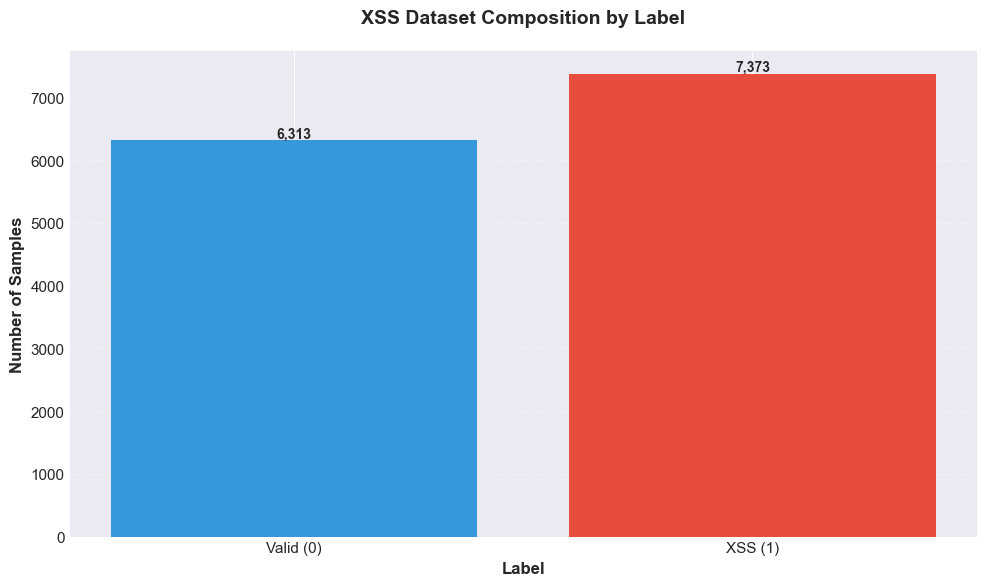


Dataset Statistics:
Total samples: 13,686

Class distribution:
  Valid (Label 0): 6,313 (46.13%)
  XSS (Label 1): 7,373 (53.87%)


In [3]:
# Display first 10 rows
df.head(10)

# Visualize dataset composition
label_counts = df['Label'].value_counts().sort_index()
label_names = ['Valid (0)', 'XSS (1)']
colors = ['#3498db', '#e74c3c']

plt.figure(figsize=(10, 6))
bars = plt.bar(label_names, label_counts.values, color=colors)
plt.title('XSS Dataset Composition by Label', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Label', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Display statistics
print(f"\nDataset Statistics:")
print(f"Total samples: {len(df):,}")
print(f"\nClass distribution:")
for label, count in label_counts.items():
    label_name = 'XSS' if label == 1 else 'Valid'
    percentage = (count / len(df)) * 100
    print(f"  {label_name} (Label {label}): {count:,} ({percentage:.2f}%)")

In [4]:
df.to_json('xss.json', 'records')

C:\Users\mps\AppData\Local\Temp\ipykernel_23916\934541685.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_json except for the argument 'path_or_buf' will be keyword-only.
  df.to_json('xss.json', 'records')


In [5]:
import json

In [6]:
with open('xss.json', 'r') as f:
    xss = json.load(f)

In [ ]:
# Display first 10 rows
xss[:10]

[{'Unnamed: 0': 0,
  'Sentence': '<li><a href="/wiki/File:Socrates.png" class="image"><img alt="Socrates.png" src="//upload.wikimedia.org/wikipedia/commons/thumb/c/cd/Socrates.png/18px-Socrates.png" decoding="async" width="18" height="28" class="noviewer" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/c/cd/Socrates.png/27px-Socrates.png 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/c/cd/Socrates.png/36px-Socrates.png 2x" data-file-width="326" data-file-height="500" /> </a> <a href="/wiki/Portal:Philosophy" title="Portal:Philosophy">Philosophy&#32;portal </a> </li> </ul>',
  'Label': 0},
 {'Unnamed: 0': 1,
  'Sentence': '<tt onmouseover="alert(1)">test</tt>',
  'Label': 1},
 {'Unnamed: 0': 2,
  'Sentence': '\t </span> <span class="reference-text">Steering for the 1995 "<a href="/wiki/History_of_autonomous_cars#1990s" class="mw-redirect" title="History of autonomous cars">No Hands Across America </a>" required "only a few human assists". ',
  'Label': 0},
 {'Unnamed: 0': 3